# Critical-Path Scheduling of an Auto-Insurance Product Launch

## Executive summary

Launching a personal auto-insurance product is a cross-functional program: actuaries price the risk, compliance files rates with the state and waits for approval, IT configures the policy-administration system, and distribution trains agents. These tasks have hard precedence relationships, so the launch date is set by the longest dependent chain through the plan -- the **critical path**.

This notebook builds an Activity-on-Node project network of eleven launch tasks and computes a full **Critical Path Method (CPM)** schedule with **PROC OPTMODEL**. CPM's forward and backward passes are linear programs over the precedence graph: the forward pass (longest path from the start) gives each task's earliest start and finish, and a backward longest-path pass gives the latest start and finish and the **total float** (schedule slack). The results below are produced entirely by the code in this notebook -- every number in the narrative is read back from the executed output.

**What the schedule shows.** On a five-day work calendar anchored at 01JUN2026, the program spans **97 working days** and finishes **13OCT2026**. Nine of the eleven tasks lie on the critical path (Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch) and carry zero float. Only the regulatory branch -- **rate filing** and **approval** -- has slack: each can slip up to **30 working days** without moving the launch, because the parallel system-build branch is the longer of the two converging paths.

## How this is built

CPM is classically a SAS/OR procedure, but its core computation is a pair of longest-path problems on the precedence graph, which PROC OPTMODEL expresses directly as small linear programs:

- **Forward pass (earliest times).** Minimize the earliest-start variables subject to `ES[successor] >= ES[predecessor] + duration + lag` for every precedence arc. At the optimum each `ES` equals the longest path from the project start, i.e. the earliest the task can begin.
- **Backward pass (latest times / float).** Compute, for each task, the longest remaining path to project end (`TAIL`). The latest start is then `makespan - TAIL`, and **total float** is `late start - early start`. Tasks with zero float are critical.

The network, durations, precedence lags, and per-task resource demands are all generated inline; there are no external inputs. Working-day calendar dates are derived with `INTNX('weekday', ...)` so weekends are skipped.

## Data

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Activity master: each launch task, its working-day duration, and the daily actuary / developer headcount it needs |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Precedence arcs of the Activity-on-Node network; `lag` is a finish-to-start delay in working days (the regulatory waiting period after approval) |

Numeric activity IDs key the network so the precedence graph reads cleanly into OPTMODEL's tuple set; the readable `activity` names are merged back onto the schedule afterward.

In [1]:
data acts;
   length activity $16;
   input id activity $ dur actuary developer;
   datalines;
1 Kickoff       3 1 0
2 MarketRsch    8 2 0
3 LossData     10 3 0
4 Pricing       9 3 1
5 RateFiling    4 1 0
6 Approval      6 1 0
7 SystemDesign 12 1 2
8 SystemBuild  18 0 3
9 UAT          15 0 2
10 AgentTrain  20 1 1
11 Launch       2 1 1
;
run;

data arcs;
   input pred succ lag;
   datalines;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
run;

/* numeric-only view of durations for OPTMODEL */
data acts_n; set acts; keep id dur; run;

NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Forward pass -- earliest start and finish

The forward pass is a longest-path LP. The constraint `ES[j] >= ES[i] + dur[i] + lag[i,j]` for every arc forces each task to start no earlier than all of its predecessors finish (plus any regulatory lag); minimizing the earliest-start variables drives each to its longest predecessor path. We write the solved `ES` values straight from the OPTMODEL variable into `fwd`.

In [2]:
proc optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var ES{NODES} >= 0;
   con prec{<i,j> in ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   min total_es = sum{k in NODES} ES[k];
   solve;

   create data fwd from [id]=NODES es=ES;
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000



NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.17.1
NOTE: PROC OPTMODEL completed.


## Backward pass -- latest times and total float

`TAIL[a]` is the longest path from task `a` through to project end, so it must cover the task's own duration and, for each successor, the lag plus that successor's tail: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimizing the tails yields the tightest such values. The project **makespan** is the largest early finish; each task's **late start** is `makespan - TAIL`, and **total float** is `late start - early start`. Float of zero marks the critical path.

In [3]:
proc optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var TAIL{NODES} >= 0;
   con base{a in NODES}: TAIL[a] >= dur[a];
   con back{<i,j> in ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   min total_tail = sum{k in NODES} TAIL[k];
   solve;

   create data bwd from [id]=NODES tail=TAIL;
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000



NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.17.1
NOTE: PROC OPTMODEL completed.


## Assemble the schedule and the calendar

We merge the early starts and tails back onto the activity master, derive the late start / finish and total float, and map the working-day offsets to calendar dates with `INTNX('weekday', ...)` so the dates fall on business days. A task is flagged **critical** when its total float is zero.

In [4]:
%let anchor = '01jun2026'd;

data sched0;
   merge acts fwd bwd; by id;
   ef = es + dur;            /* early finish */
run;

proc means data=sched0 noprint;
   output out=mk(drop=_type_ _freq_) max(ef)=makespan;
run;

data sched;
   if _n_=1 then set mk;
   set sched0;
   retain mspan;
   if _n_=1 then mspan = makespan;
   ls = mspan - tail;        /* late start  */
   lf = ls + dur;            /* late finish */
   tfloat = ls - es;         /* total float */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   length cclass $10;
   if critical then cclass='Critical';
   else cclass='Float';
   format e_start e_finish l_start l_finish date9.;
run;

proc sort data=sched out=sched_es; by es id; run;

NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## The CPM schedule

Early/late start and finish are in working days from the 01JUN2026 anchor (day 0). Tasks in the **Critical** class have zero total float.

In [5]:
title 'CPM schedule -- working-day times and total float';
proc print data=sched_es noobs label;
   var activity dur es ef ls lf tfloat cclass;
   label activity='Activity' dur='Dur(wd)' es='ES' ef='EF'
         ls='LS' lf='LF' tfloat='Total Float' cclass='Class';
run;

                                   CPM schedule -- working-day times and total float                                    


    Activity  Dur(wd)  ES  EF  LS  LF  Total Float     Class
------------  -------  --  --  --  --  -----------  --------
Kickoff             3   0   3   0   3            0  Critical
MarketRsch          8   3  11   3  11            0  Critical
LossData           10  11  21  11  21            0  Critical
Pricing             9  21  30  21  30            0  Critical
RateFiling          4  30  34  60  64           30  Float
SystemDesign       12  30  42  30  42            0  Critical
Approval            6  34  40  64  70           30  Float
SystemBuild        18  42  60  42  60            0  Critical
UAT                15  60  75  60  75            0  Critical
AgentTrain         20  75  95  75  95            0  Critical
Launch              2  95  97  95  97            0  Critical



NOTE: Option TITLE changed to CPM schedule -- working-day times and total float.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


The early-start column traces the dependent chain: Kickoff begins at day 0, and each downstream task starts when its predecessors finish. The project completes at the largest early finish.

## The critical path

Listing only the zero-float tasks, with their calendar dates, gives the chain that sets the launch date. Any slip on these tasks moves the launch day-for-day.

In [6]:
title 'Critical path (Total Float = 0) with calendar dates';
proc print data=sched_es noobs label;
   where critical=1;
   var activity dur e_start e_finish;
   label activity='Activity' dur='Dur(wd)'
         e_start='Early Start' e_finish='Early Finish';
run;

data mkrep;
   set mk;
   anchor = &anchor;
   finish = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor finish date9.;
run;
title 'Project span';
proc print data=mkrep noobs label;
   var anchor makespan finish;
   label anchor='Anchor (Day 0)'
         makespan='Makespan (working days)'
         finish='Projected finish';
run;

                                  Critical path (Total Float = 0) with calendar dates                                   


    Activity  Dur(wd)  Early Start  Early Finish
------------  -------  -----------  ------------
Kickoff             3    01JUN2026     03JUN2026
MarketRsch          8    04JUN2026     15JUN2026
LossData           10    16JUN2026     29JUN2026
Pricing             9    30JUN2026     10JUL2026
SystemDesign       12    13JUL2026     28JUL2026
SystemBuild        18    29JUL2026     21AUG2026
UAT                15    24AUG2026     11SEP2026
AgentTrain         20    14SEP2026     09OCT2026
Launch              2    12OCT2026     13OCT2026

                                                      Project span                                                      


Anchor (Day 0)  Makespan (working days)  Projected finish
--------------  -----------------------  ----------------
     01JUN2026                       97         13OCT2026



NOTE: Option TITLE changed to Critical path (Total Float = 0) with calendar dates.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Project span.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Where the slack is

The non-critical tasks are the regulatory branch. Their late start / finish show how far each can move before it would begin to push the launch. Free float here equals total float because no other task depends on them until they rejoin at agent training.

In [7]:
title 'Non-critical activities and their schedule slack';
proc print data=sched_es noobs label;
   where critical=0;
   var activity dur e_start e_finish l_start l_finish tfloat;
   label activity='Activity' dur='Dur(wd)'
         e_start='Early Start' e_finish='Early Finish'
         l_start='Late Start' l_finish='Late Finish'
         tfloat='Total Float';
run;

                                    Non-critical activities and their schedule slack                                    


  Activity  Dur(wd)  Early Start  Early Finish  Late Start  Late Finish  Total Float
----------  -------  -----------  ------------  ----------  -----------  -----------
RateFiling        4    13JUL2026     16JUL2026   24AUG2026    27AUG2026           30
Approval          6    17JUL2026     24JUL2026   28AUG2026    04SEP2026           30



NOTE: Option TITLE changed to Non-critical activities and their schedule slack.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Schedule waterfall

A high-low bar per task, drawn from its early start (bar bottom) to its early finish (bar top) in early-start order, gives a Gantt-style waterfall of the plan. Each bar's height is the task duration, and the critical bars chain together into a staircase that climbs to the 97-working-day makespan. The tasks with slack are the short bars that *don't* carry the staircase upward: they sit alongside a taller parallel critical bar instead of advancing the climb.

                                    Auto-product launch -- early-schedule waterfall                                     



NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Auto-product launch -- early-schedule waterfall.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


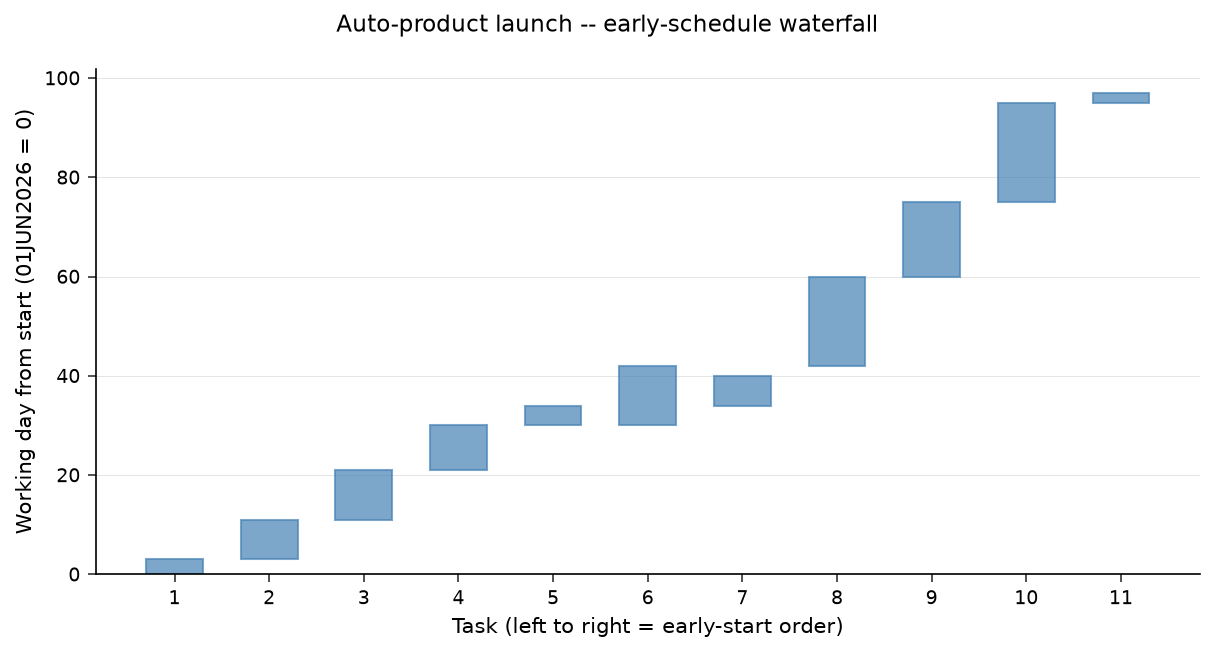

In [8]:
data gantt; set sched_es;
   ord = es;          /* numeric x = early-start order */
run;
proc sort data=gantt; by ord activity; run;
data gantt; set gantt; ax = _n_; run;   /* compact 1..11 x index */

ods graphics on / imagename='gantt' width=820px height=440px;
title 'Auto-product launch -- early-schedule waterfall';
proc sgplot data=gantt;
   highlow x=ax low=es high=ef / type=bar barwidth=0.7;
   xaxis label='Task (left to right = early-start order)'
         integer values=(1 to 11 by 1);
   yaxis label='Working day from start (01JUN2026 = 0)' grid;
run;
ods graphics off;

Reading left to right, the critical bars step continuously up the chain. The two short bars that interrupt that climb -- **rate filing** (working days 30-34) and **approval** (34-40) -- are the activities that carry float. Both branch off after pricing at day 30, but the parallel critical bar beside them (**system design**, days 30-42, then system build to day 60) towers above and overtakes them, so neither rate filing nor approval lifts the staircase. That gap between the short regulatory bars and the rising build bars is exactly the schedule slack quantified below.

## Total float by task

Plotting each task's total float makes the critical path unmistakable: every critical task sits at zero, and only the two regulatory tasks rise above it.

                                     Total float by task (0 = on the critical path)                                     



NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Total float by task (0 = on the critical path).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


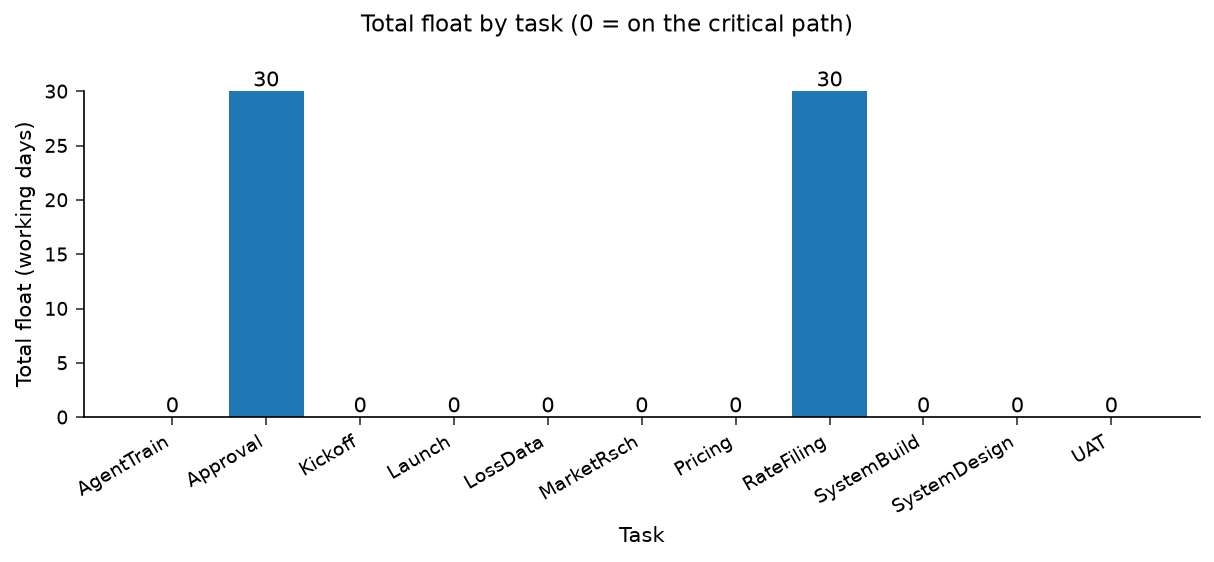

In [9]:
ods graphics on / imagename='float' width=820px height=380px;
title 'Total float by task (0 = on the critical path)';
proc sgplot data=sched_es;
   vbar activity / response=tfloat datalabel;
   xaxis label='Task' fitpolicy=rotatethin;
   yaxis label='Total float (working days)';
run;
ods graphics off;

## Resource loading under the early schedule

Beyond timing, the plan competes for two specialist pools. Expanding each task across the working days it occupies and summing the daily demand gives the resource-loading profile -- how many actuaries and developers the plan needs each day if every task starts as early as possible. The peak is the most capacity the program ever requires at once.

                                      Peak daily resource loading (early schedule)                                      

                                                  The MEANS Procedure

 Variable       Maximum
 ----------------------
 actuaries            3
 developers           3
 ----------------------

                               Daily actuary & developer loading under the early schedule                               



NOTE: DATA load


NOTE: Read 11 rows from sched.
NOTE: Wrote load (107 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 97 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Read 97 rows from rprofile.
NOTE: Wrote rprofile (97 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Peak daily resource loading (early schedule).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Daily actuary & developer loading under the early schedule.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


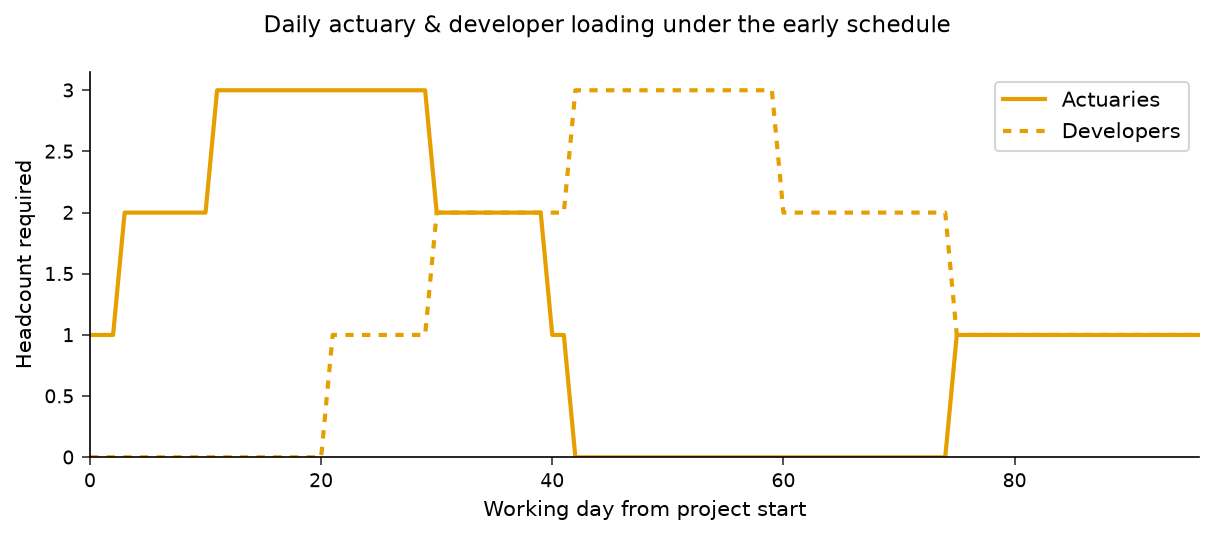

In [10]:
data load;
   set sched;
   do d = es to ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      output;
   end;
   keep day a_use d_use;
run;

proc means data=load noprint nway;
   class day;
   var a_use d_use;
   output out=rprofile(drop=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
run;
proc sort data=rprofile; by day; run;

title 'Peak daily resource loading (early schedule)';
proc means data=rprofile max maxdec=0;
   var actuaries developers;
run;

ods graphics on / imagename='resload' width=820px height=360px;
title 'Daily actuary & developer loading under the early schedule';
proc sgplot data=rprofile;
   series x=day y=actuaries  /
          lineattrs=(thickness=2) legendlabel='Actuaries';
   series x=day y=developers /
          lineattrs=(thickness=2 pattern=shortdash)
          legendlabel='Developers';
   xaxis label='Working day from project start';
   yaxis label='Headcount required' min=0;
   keylegend / location=inside position=topright;
run;
ods graphics off;

## Interpreting the results

- **The launch date is set by the build track, not the regulatory track.** The critical path runs Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch, for a makespan of 97 working days (finishing 13OCT2026). Every one of these tasks has zero float, so any delay on them pushes the launch day-for-day.

- **The regulatory branch has a month of slack.** Rate filing and approval each carry 30 working days of total float. After pricing finishes they can start as late as their late-start dates and still rejoin agent training on time, because the parallel system-build branch (system design -> system build -> UAT) is the longer of the two paths feeding the launch. In planning terms, the filing is *not* the binding constraint here -- the policy-system build is.

- **Specialist demand peaks at different phases.** The loading profile shows actuary demand peaking early (through pricing) and developer demand peaking later (through the system build), each topping out at three people per day. Because the two peaks fall in different phases, a small, sequential specialist team can staff the plan -- the program does not need its maximum actuary and developer headcount simultaneously.

**Business takeaway.** CPM turns a list of launch tasks into an actionable schedule: it identifies the build-track activities the insurer must protect to hit 13OCT2026, quantifies the month of slack available on the regulatory filing, and shows that staggered actuary and developer peaks let a lean specialist team deliver the plan.

*Implementation note:* SAS computes this with PROC CPM (SAS/OR). Jenner reaches the same forward/backward critical-path result with PROC OPTMODEL by solving the two longest-path linear programs that underlie the method.